📊 Diabetes Prediction Project
This project analyzes the Diabetes dataset using Data Analysis and Machine Learning techniques.

### Objectives
- Data cleaning and preprocessing
- Statistical analysis
- Training multiple ML models
- Model evaluation with Cross Validation
- Clustering analysis

Libraries used: NumPy, Pandas, Matplotlib, Seaborn, Scikit-Learn

## 📦 Import Libraries
In this section, we import all required libraries for data analysis and machine learning.

In [ ]:
# Add project root directory to system path
import sys
import os
from pathlib import Path

# Import required libraries
sys.path.append(str(Path("..").resolve()))  

# Moduls
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.pipeline import Pipeline
from src.visualization import Visualizer
from src.impurity import Impurity


from scipy.stats import pearsonr


## 📂 Load Dataset
We load the diabetes dataset and inspect its structure.

In [2]:
df = pd.read_csv(r"D:\aylinprograming\D&Ml\Final Project\data\diabetes.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [17]:
df.sort_values(by="BMI", ascending=False).head()
df.isna().sum()
df.describe()
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


## NumPy Statistical Analysis
In this section, we compute statistical measures manually using NumPy.

In [ ]:
# Separate features and target variable
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [ ]:
# Convert DataFrame to NumPy array for statistical analysis
X_np = X.values  

print("Mean:", np.mean(X_np, axis=0))
print("Variance:", np.var(X_np, axis=0))
print("Median:", np.median(X_np, axis=0))

cov_matrix = np.cov(X_np.T)
print("Covariance Matrix:\n", cov_matrix)

Mean: [  3.84505208 120.89453125  69.10546875  20.53645833  79.79947917
  31.99257812   0.4718763   33.24088542]
Variance: [1.13392724e+01 1.02091726e+03 3.74159449e+02 2.54141900e+02
 1.32638869e+04 6.20790465e+01 1.09635697e-01 1.38122964e+02]
Median: [  3.     117.      72.      23.      30.5     32.       0.3725  29.    ]
Covariance Matrix:
 [[ 1.13540563e+01  1.39471307e+01  9.21453818e+00 -4.39004101e+00
  -2.85552307e+01  4.69774181e-01 -3.74259714e-02  2.15706198e+01]
 [ 1.39471307e+01  1.02224831e+03  9.44309556e+01  2.92391827e+01
   1.22093580e+03  5.57269867e+01  1.45487481e+00  9.90828054e+01]
 [ 9.21453818e+00  9.44309556e+01  3.74647271e+02  6.40293962e+01
   1.98378412e+02  4.30046951e+01  2.64637574e-01  5.45234528e+01]
 [-4.39004101e+00  2.92391827e+01  6.40293962e+01  2.54473245e+02
   8.02979941e+02  4.93738694e+01  9.72135546e-01 -2.13810232e+01]
 [-2.85552307e+01  1.22093580e+03  1.98378412e+02  8.02979941e+02
   1.32811801e+04  1.79775172e+02  7.06668051e+00 -5.7

In [20]:
pd.crosstab(df["Outcome"], df["Age"])
pd.pivot_table(df, values="BMI", index="Outcome", aggfunc="mean")

,BMI
Outcome,
0,30.304200
1,35.142537


## 🔍 Exploratory Data Analysis
We explore distributions, correlations, and outliers.

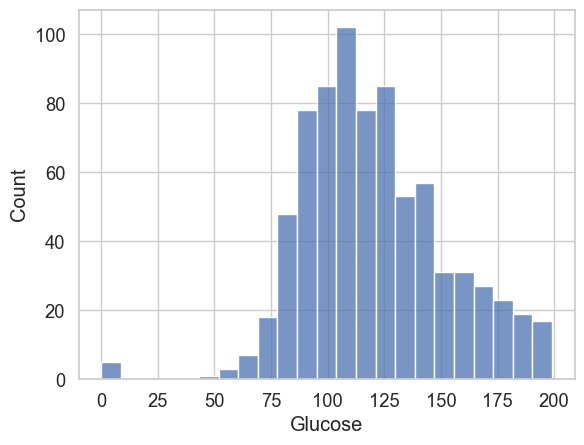

In [9]:
viz = Visualizer()
sns.histplot(df["Glucose"])
plt.show()

# sns.boxplot(x=df["BMI"])
# plt.show()

# viz.heatmap(df)

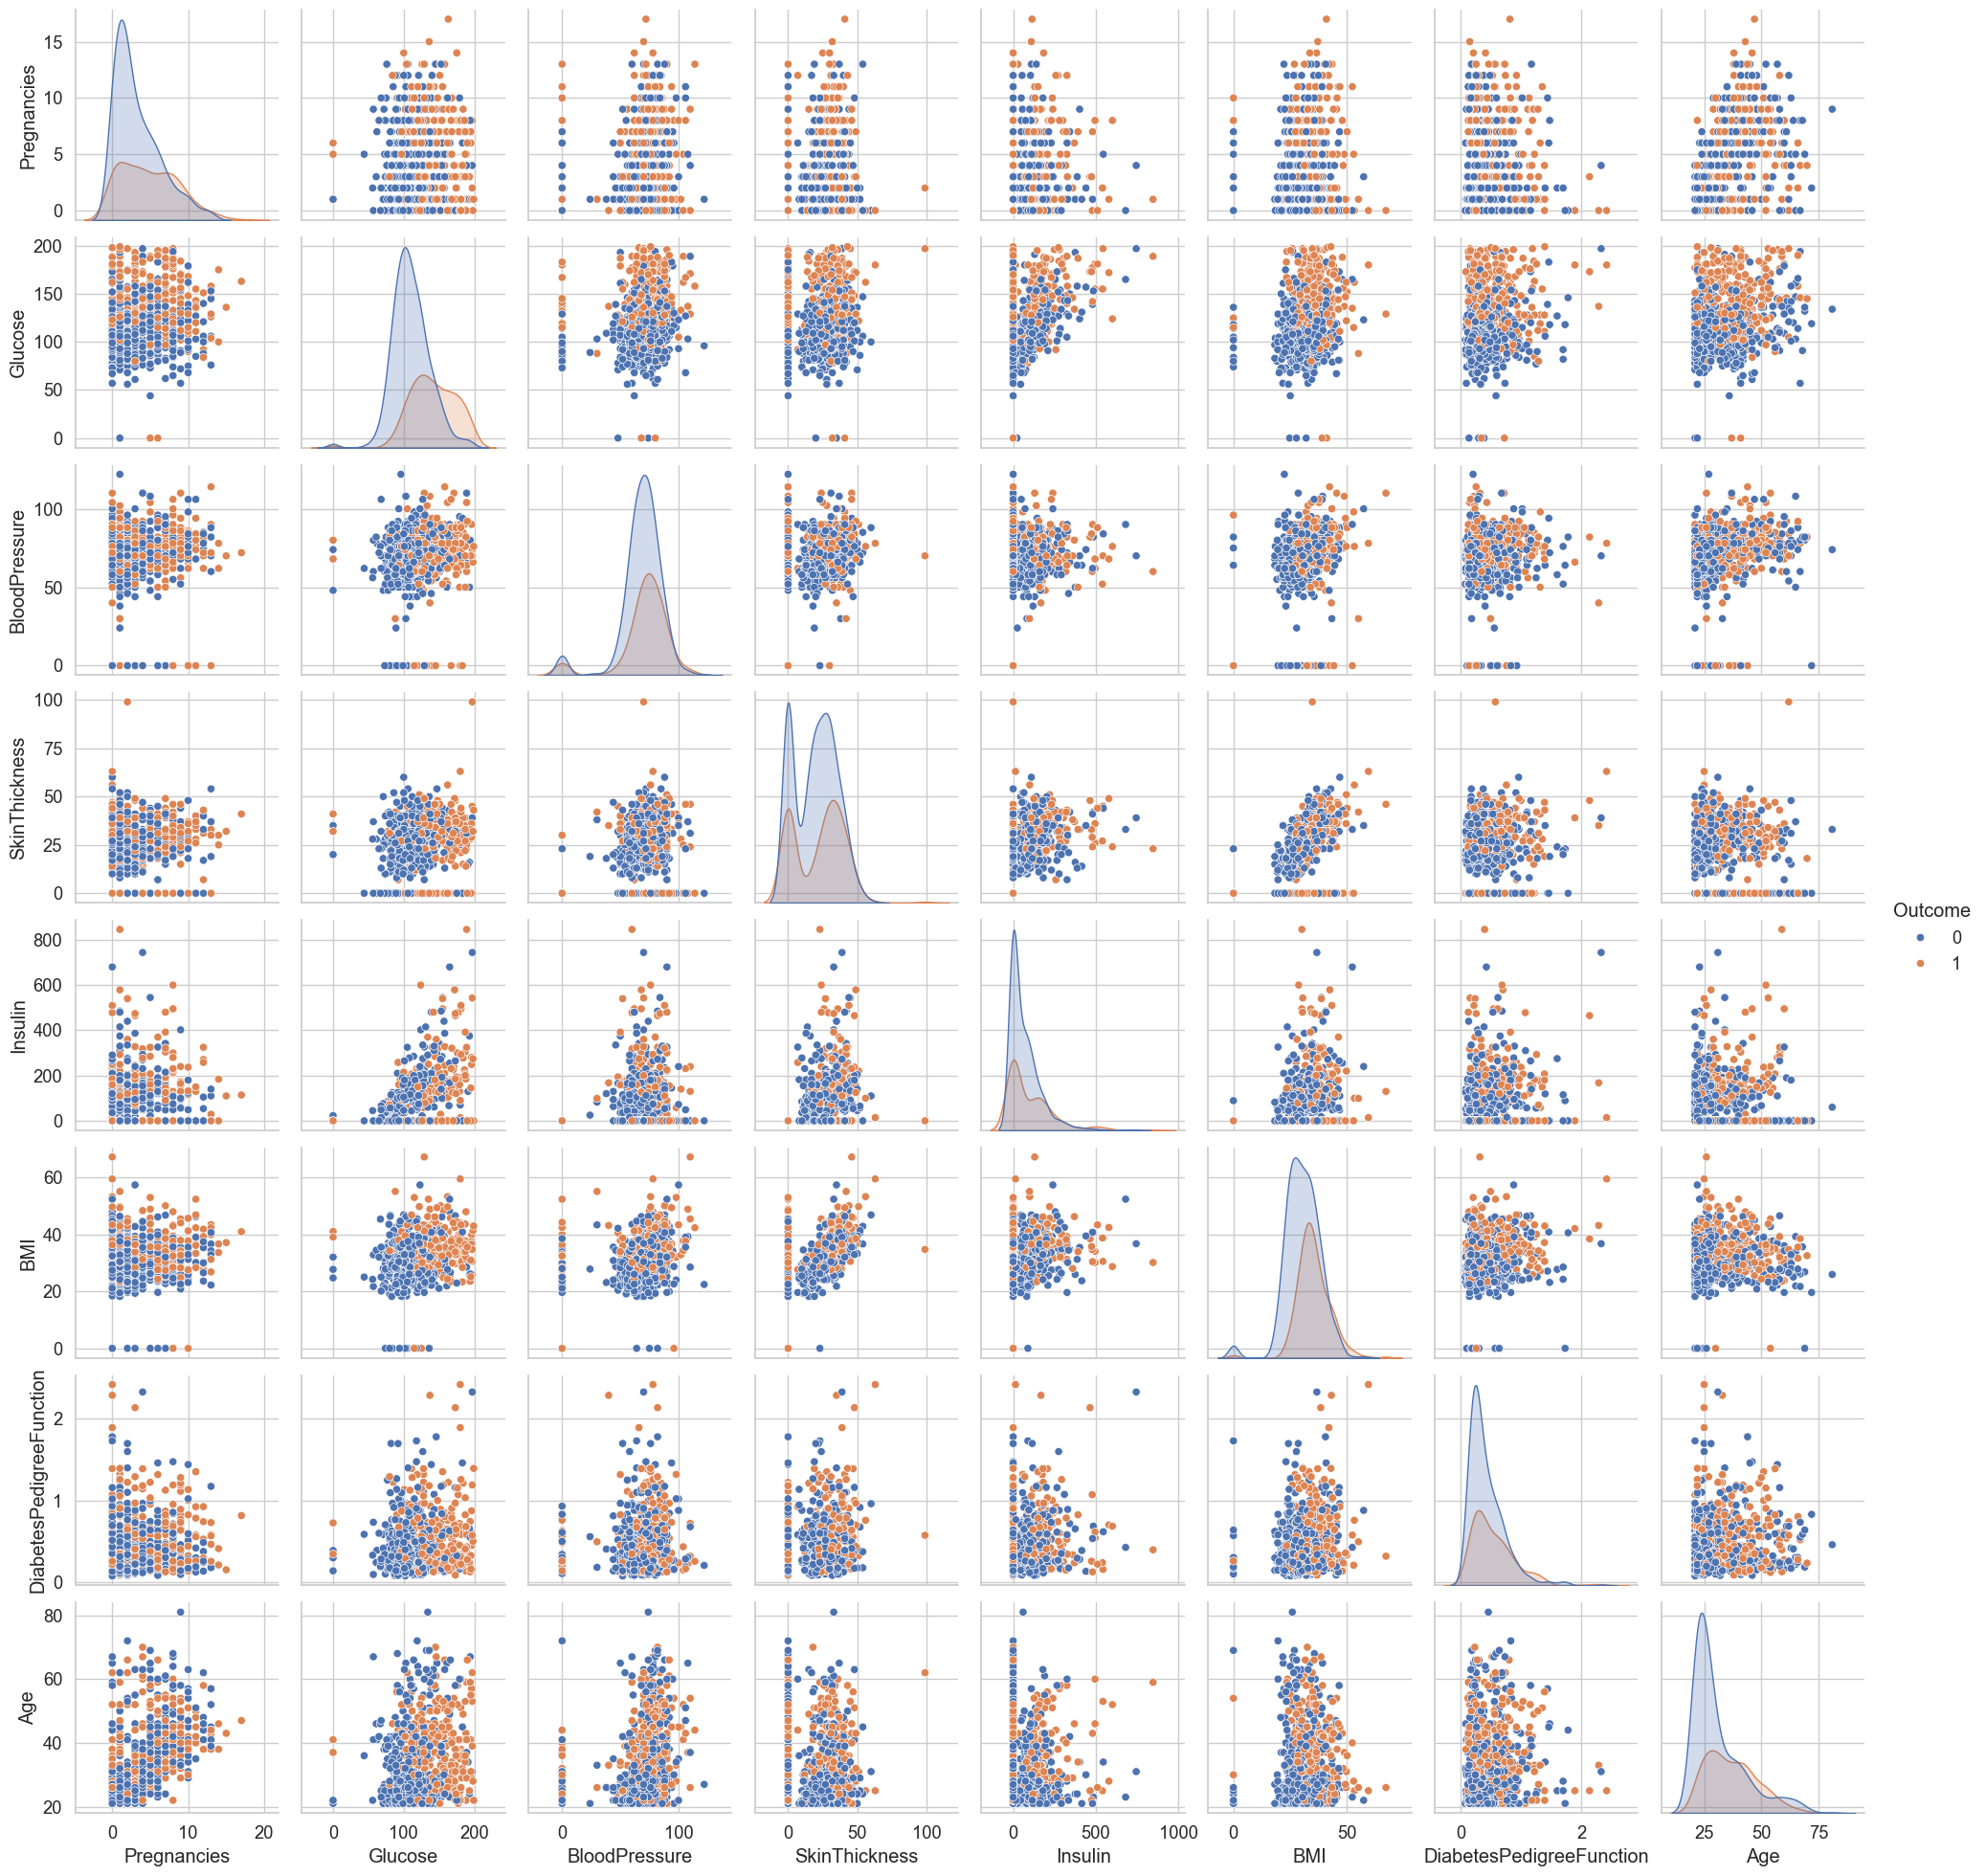

In [ ]:
sns.pairplot(df, hue="Outcome")

## 📐 Statistical Analysis
We compute mean, variance, correlation, entropy, and Gini index.

In [ ]:
print("Entropy:", Impurity.entropy(df["Outcome"]))
print("Gini:", Impurity.gini(df["Outcome"]))
print("Correlation:\n", df.corr())

Entropy: 0.9331343137553931
Gini: 0.45437282986111116
Correlation:
                           Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.129459       0.141282      -0.081672   
Glucose                      0.129459  1.000000       0.152590       0.057328   
BloodPressure                0.141282  0.152590       1.000000       0.207371   
SkinThickness               -0.081672  0.057328       0.207371       1.000000   
Insulin                     -0.073535  0.331357       0.088933       0.436783   
BMI                          0.017683  0.221071       0.281805       0.392573   
DiabetesPedigreeFunction    -0.033523  0.137337       0.041265       0.183928   
Age                          0.544341  0.263514       0.239528      -0.113970   
Outcome                      0.221898  0.466581       0.065068       0.074752   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies              -0.073535  0.017683   

Pearson correlation:

In [ ]:
pearsonr(df["Glucose"], df["BMI"])

PearsonRResult(statistic=0.22107106945898297, pvalue=5.891412527084351e-10)

Chi-Square:

In [ ]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["Outcome"], df["Age"])
chi2_contingency(table)

Chi2ContingencyResult(statistic=140.9375197044156, pvalue=2.3069818149863462e-10, dof=51, expected_freq=array([[41.015625  , 46.875     , 24.73958333, 29.94791667, 31.25      ,
        21.484375  , 20.83333333, 22.78645833, 18.88020833, 13.671875  ,
        15.625     , 10.41666667, 11.06770833,  9.11458333,  6.51041667,
        10.41666667, 12.36979167, 10.41666667,  7.8125    ,  8.46354167,
        14.32291667, 11.71875   ,  8.46354167,  5.20833333,  9.765625  ,
         8.46354167,  3.90625   ,  3.25520833,  3.25520833,  5.20833333,
         5.20833333,  5.20833333,  3.25520833,  3.90625   ,  2.60416667,
         1.953125  ,  3.25520833,  4.55729167,  1.953125  ,  3.25520833,
         1.30208333,  2.60416667,  2.60416667,  0.65104167,  1.953125  ,
         2.60416667,  1.953125  ,  0.65104167,  1.30208333,  0.65104167,
         0.65104167,  0.65104167],
       [21.984375  , 25.125     , 13.26041667, 16.05208333, 16.75      ,
        11.515625  , 11.16666667, 12.21354167, 10.11979167

## 🧹 Data Preprocessing
We remove fake zeros, duplicates, and normalize the data.

In [ ]:
from src.preprocessing import Preprocessor

prep = Preprocessor(df)
prep.remove_fake_zeros().remove_duplicates()

X, y = prep.normalize_df("Outcome")
print("Class balance:", prep.class_count("Outcome"))

Class balance: Outcome
0    500
1    268
Name: count, dtype: int64


🔹 Missing Values Handling

In [27]:
df.replace(0, np.nan, inplace=True)
df.fillna(df.mean(), inplace=True)

🔹 Normalization

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

🔹 Dummy Variables

In [ ]:
# pd.get_dummies(df, columns=["Gender"], drop_first=True)

## 🤖 Training Machine Learning Models
We train multiple classification models and compare their performance.

In [3]:
scores = Pipeline().run()
scores

2026-02-27 19:31:39,731 - INFO - Loading data from: D:\aylinprograming\D&Ml\Final Project\data\diabetes.csv
2026-02-27 19:31:39,732 - INFO - Loading data from D:\aylinprograming\D&Ml\Final Project\data\diabetes.csv
2026-02-27 19:31:39,740 - INFO - Splitting data...
2026-02-27 19:31:39,754 - INFO - Initializing models...
2026-02-27 19:31:39,755 - INFO - Training models...
2026-02-27 19:31:39,756 - INFO - Training DecisionTree...
2026-02-27 19:31:39,812 - INFO - DecisionTree CV Mean Accuracy: 0.713
2026-02-27 19:31:39,826 - INFO - DecisionTree Test Accuracy: 0.792
2026-02-27 19:31:39,827 - INFO - Training RandomForest...



===== DecisionTree Classification Report =====
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       100
           1       0.70      0.70      0.70        54

    accuracy                           0.79       154
   macro avg       0.77      0.77      0.77       154
weighted avg       0.79      0.79      0.79       154



2026-02-27 19:31:42,283 - INFO - RandomForest CV Mean Accuracy: 0.774
2026-02-27 19:31:42,313 - INFO - RandomForest Test Accuracy: 0.740
2026-02-27 19:31:42,315 - INFO - Training LogisticRegression...



===== RandomForest Classification Report =====
              precision    recall  f1-score   support

           0       0.78      0.83      0.81       100
           1       0.65      0.57      0.61        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.71       154
weighted avg       0.73      0.74      0.74       154



2026-02-27 19:31:42,661 - INFO - LogisticRegression CV Mean Accuracy: 0.779
2026-02-27 19:31:42,673 - INFO - LogisticRegression Test Accuracy: 0.714
2026-02-27 19:31:42,674 - INFO - Training KNN...
2026-02-27 19:31:42,786 - INFO - KNN CV Mean Accuracy: 0.741
2026-02-27 19:31:42,818 - INFO - KNN Test Accuracy: 0.669
2026-02-27 19:31:42,819 - INFO - Best Model: DecisionTree
2026-02-27 19:31:42,819 - INFO - Best Accuracy: 0.792



===== LogisticRegression Classification Report =====
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154


===== KNN Classification Report =====
              precision    recall  f1-score   support

           0       0.73      0.77      0.75       100
           1       0.53      0.48      0.50        54

    accuracy                           0.67       154
   macro avg       0.63      0.63      0.63       154
weighted avg       0.66      0.67      0.66       154



2026-02-27 19:31:43,320 - INFO - Best model saved successfully.


{'scores': {'DecisionTree': 0.7922077922077922,
  'RandomForest': 0.7402597402597403,
  'LogisticRegression': 0.7142857142857143,
  'KNN': 0.6688311688311688},
 'best_model_name': 'DecisionTree',
 'best_model': DecisionTreeClassifier(max_depth=5, random_state=42),
 'all_models': {'DecisionTree': DecisionTreeClassifier(max_depth=5, random_state=42),
  'RandomForest': RandomForestClassifier(max_depth=6, n_estimators=200, random_state=42),
  'LogisticRegression': LogisticRegression(max_iter=1000),
  'KNN': KNeighborsClassifier()},
 'X_train':      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
 353            1       90             62             12       43  27.2   
 711            5      126             78             27       22  29.6   
 373            2      105             58             40       94  34.9   
 46             1      146             56              0        0  29.7   
 682            0       95             64             39      105  44.6   
 ..  

## 📊 Model Evaluation
We compare model accuracy and cross-validation scores.

D:\aylinprograming\D&Ml\Final Project\src\visualization.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


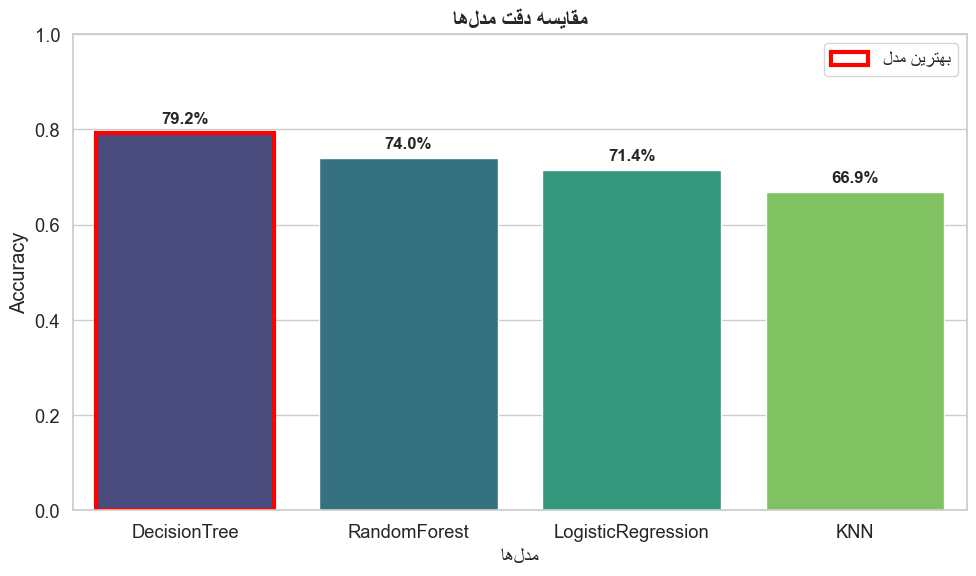

<function matplotlib.pyplot.show(close=None, block=None)>

In [7]:
names = list(scores["scores"].keys())
vals  = list(scores["scores"].values())

Visualizer().compare_models(names, vals)
plt.show

In [11]:
model_scores = scores["scores"]

pd.DataFrame.from_dict(model_scores, orient="index", columns=["Accuracy"])

,Accuracy
DecisionTree,0.792208
RandomForest,0.740260
LogisticRegression,0.714286
KNN,0.668831


## 🔵 Unsupervised Learning (Clustering)
We apply K-Means clustering to discover hidden patterns.

c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


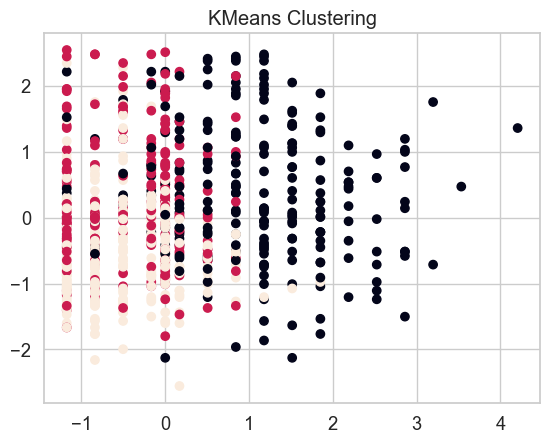

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=clusters)
plt.title("KMeans Clustering")
plt.show()

In [15]:
# from src.pipeline import Pipeline

# data_path = r"D:\aylinprograming\D&Ml\Final Project\data\diabetes.csv"

# pipe = Pipeline()
# results = pipe.run(data_path)

In [6]:
pipe = Pipeline()
results = pipe.run(data_path)

scores = results["scores"]
best_model = results["best_model"]
best_name = results["best_model_name"]
X_test = results["X_test"]
y_test = results["y_test"]
df = results["dataframe"]

2026-02-27 19:32:27,598 - INFO - Loading data from: D:\aylinprograming\D&Ml\Final Project\data\diabetes.csv
2026-02-27 19:32:27,598 - INFO - Loading data from D:\aylinprograming\D&Ml\Final Project\data\diabetes.csv
2026-02-27 19:32:27,603 - INFO - Splitting data...
2026-02-27 19:32:27,610 - INFO - Initializing models...
2026-02-27 19:32:27,610 - INFO - Training models...
2026-02-27 19:32:27,612 - INFO - Training DecisionTree...
2026-02-27 19:32:27,661 - INFO - DecisionTree CV Mean Accuracy: 0.713
2026-02-27 19:32:27,676 - INFO - DecisionTree Test Accuracy: 0.792
2026-02-27 19:32:27,678 - INFO - Training RandomForest...



===== DecisionTree Classification Report =====
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       100
           1       0.70      0.70      0.70        54

    accuracy                           0.79       154
   macro avg       0.77      0.77      0.77       154
weighted avg       0.79      0.79      0.79       154



2026-02-27 19:32:30,308 - INFO - RandomForest CV Mean Accuracy: 0.774
2026-02-27 19:32:30,338 - INFO - RandomForest Test Accuracy: 0.740
2026-02-27 19:32:30,339 - INFO - Training LogisticRegression...



===== RandomForest Classification Report =====
              precision    recall  f1-score   support

           0       0.78      0.83      0.81       100
           1       0.65      0.57      0.61        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.71       154
weighted avg       0.73      0.74      0.74       154



2026-02-27 19:32:30,581 - INFO - LogisticRegression CV Mean Accuracy: 0.779
2026-02-27 19:32:30,594 - INFO - LogisticRegression Test Accuracy: 0.714
2026-02-27 19:32:30,597 - INFO - Training KNN...
2026-02-27 19:32:30,678 - INFO - KNN CV Mean Accuracy: 0.741
2026-02-27 19:32:30,704 - INFO - KNN Test Accuracy: 0.669
2026-02-27 19:32:30,704 - INFO - Best Model: DecisionTree
2026-02-27 19:32:30,705 - INFO - Best Accuracy: 0.792
2026-02-27 19:32:30,709 - INFO - Best model saved successfully.



===== LogisticRegression Classification Report =====
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154


===== KNN Classification Report =====
              precision    recall  f1-score   support

           0       0.73      0.77      0.75       100
           1       0.53      0.48      0.50        54

    accuracy                           0.67       154
   macro avg       0.63      0.63      0.63       154
weighted avg       0.66      0.67      0.66       154



In [7]:
results = pipe.run(data_path)
scores = results["scores"]

2026-02-27 19:32:35,176 - INFO - Loading data from: D:\aylinprograming\D&Ml\Final Project\data\diabetes.csv
2026-02-27 19:32:35,176 - INFO - Loading data from D:\aylinprograming\D&Ml\Final Project\data\diabetes.csv
2026-02-27 19:32:35,182 - INFO - Splitting data...
2026-02-27 19:32:35,187 - INFO - Initializing models...
2026-02-27 19:32:35,187 - INFO - Training models...
2026-02-27 19:32:35,189 - INFO - Training DecisionTree...
2026-02-27 19:32:35,255 - INFO - DecisionTree CV Mean Accuracy: 0.713
2026-02-27 19:32:35,284 - INFO - DecisionTree Test Accuracy: 0.792
2026-02-27 19:32:35,285 - INFO - Training RandomForest...



===== DecisionTree Classification Report =====
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       100
           1       0.70      0.70      0.70        54

    accuracy                           0.79       154
   macro avg       0.77      0.77      0.77       154
weighted avg       0.79      0.79      0.79       154



2026-02-27 19:32:37,864 - INFO - RandomForest CV Mean Accuracy: 0.774
2026-02-27 19:32:37,909 - INFO - RandomForest Test Accuracy: 0.740
2026-02-27 19:32:37,911 - INFO - Training LogisticRegression...



===== RandomForest Classification Report =====
              precision    recall  f1-score   support

           0       0.78      0.83      0.81       100
           1       0.65      0.57      0.61        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.71       154
weighted avg       0.73      0.74      0.74       154



2026-02-27 19:32:38,136 - INFO - LogisticRegression CV Mean Accuracy: 0.779
2026-02-27 19:32:38,153 - INFO - LogisticRegression Test Accuracy: 0.714
2026-02-27 19:32:38,154 - INFO - Training KNN...
2026-02-27 19:32:38,267 - INFO - KNN CV Mean Accuracy: 0.741
2026-02-27 19:32:38,300 - INFO - KNN Test Accuracy: 0.669
2026-02-27 19:32:38,301 - INFO - Best Model: DecisionTree
2026-02-27 19:32:38,302 - INFO - Best Accuracy: 0.792
2026-02-27 19:32:38,308 - INFO - Best model saved successfully.



===== LogisticRegression Classification Report =====
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154


===== KNN Classification Report =====
              precision    recall  f1-score   support

           0       0.73      0.77      0.75       100
           1       0.53      0.48      0.50        54

    accuracy                           0.67       154
   macro avg       0.63      0.63      0.63       154
weighted avg       0.66      0.67      0.66       154



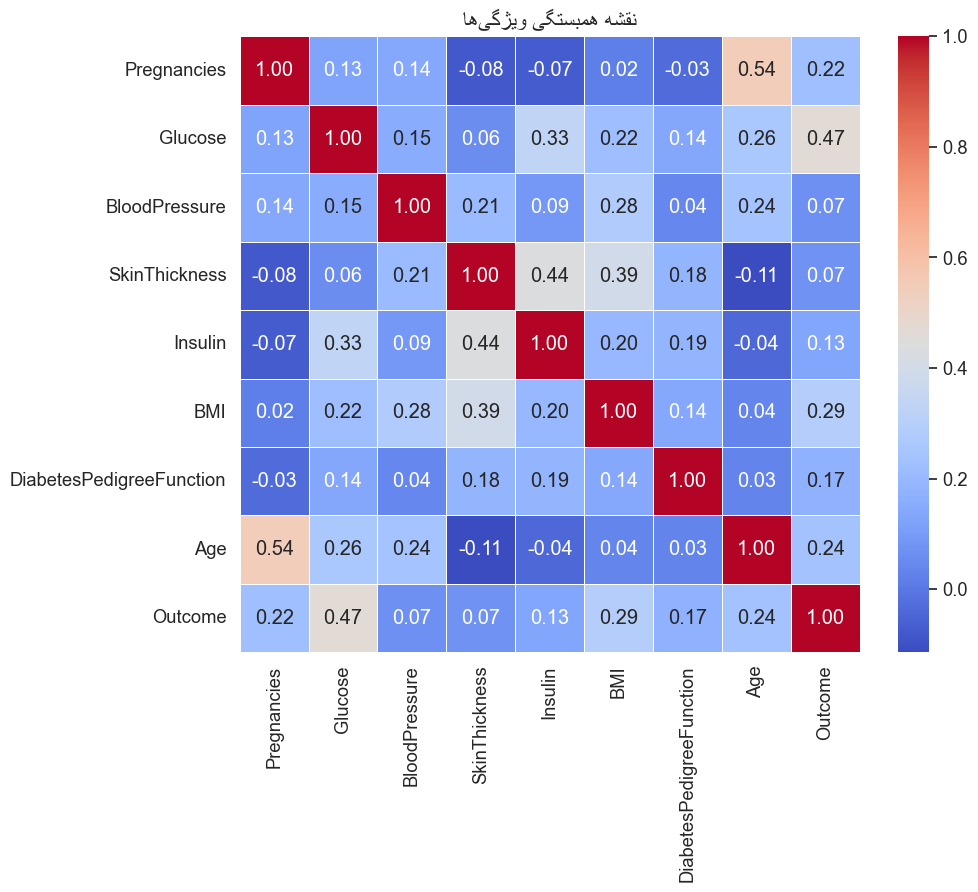

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,8))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=16)
plt.show()

In [ ]:
# import seaborn as sns
# import pandas as pd

# df = pd.read_csv(data_path)

# # Pairplot با Outcome
# sns.pairplot(df, hue="Outcome")
# plt.suptitle(vis.fa("Pairplot ویژگی‌ها با Outcome"), y=1.02)
# plt.show()

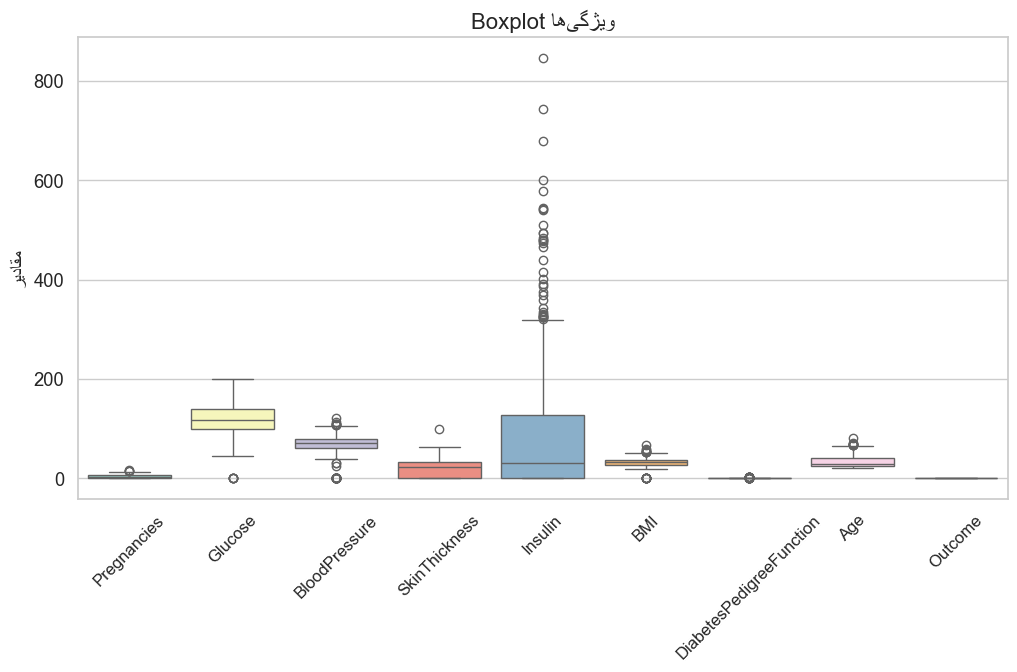

In [ ]:
# Feature distribution and outlier detection
plt.figure(figsize=(12,6))

sns.boxplot(data=df, palette="Set3")

plt.title("Feature Distribution Boxplot", fontsize=16)
plt.xticks(rotation=45, fontsize=12)
plt.ylabel("Feature Values", fontsize=14)

plt.show()

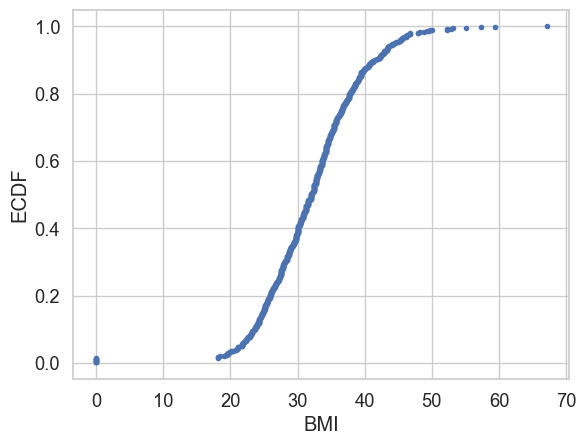

In [37]:
def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y

x, y = ecdf(df["BMI"])

plt.figure()
plt.plot(x, y, marker='.', linestyle='none')
plt.xlabel("BMI")
plt.ylabel("ECDF")
plt.show()

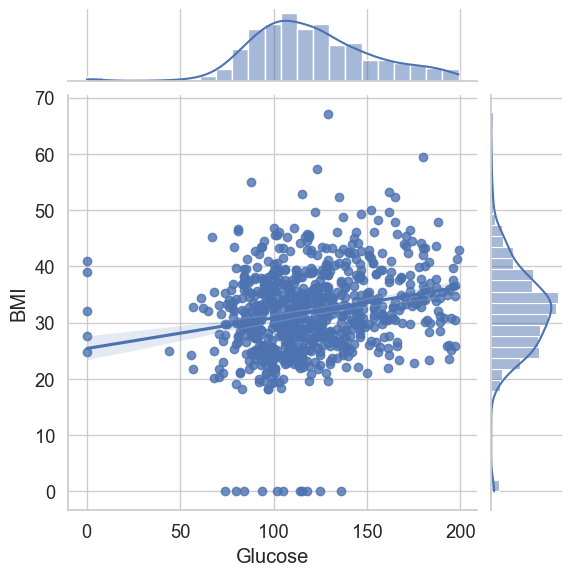

In [ ]:
sns.jointplot(data=df, x="Glucose", y="BMI", kind="reg")

In [ ]:
# plt.figure(figsize=(10,6))
# sns.boxplot(data=df)
# plt.title(vis.fa("Boxplot ویژگی‌ها"))
# plt.xticks(rotation=45)
# plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_24396\2436219066.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[features[i] for i in indices], y=importances[indices], palette="magma")


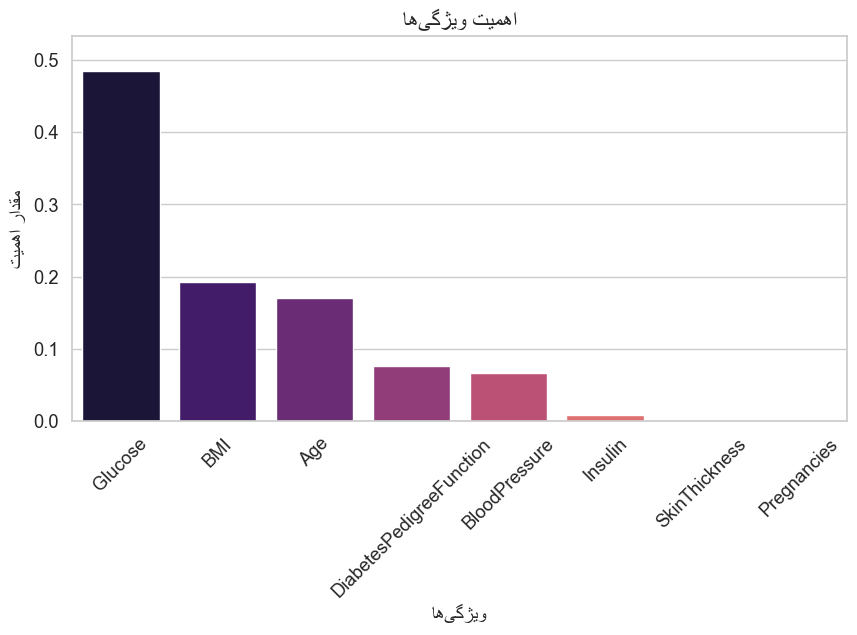

In [ ]:
   # Feature importance analysis
if hasattr(best_model, "feature_importances_"):

    importances = best_model.feature_importances_

    features = df.drop("Outcome", axis=1).columns

    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(10,5))

    sns.barplot(
        x=[features[i] for i in indices],
        y=importances[indices],
        palette="magma"
    )

    plt.title("Feature Importance Analysis", fontsize=16)
    plt.ylabel("Importance Score", fontsize=14)
    plt.xlabel("Features", fontsize=14)

    plt.xticks(rotation=45)
    plt.ylim(0, max(importances)*1.1)

    plt.show()    

🔹Confusion Matrix Visualization

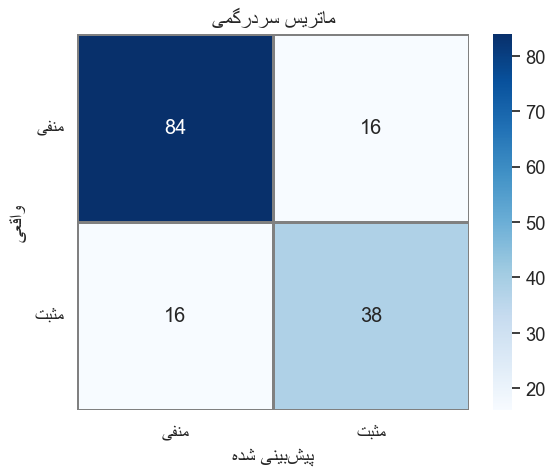

In [ ]:
# Load the best trained model
from sklearn.metrics import confusion_matrix
import joblib
from src.config import Config

cfg = Config()

best_model = joblib.load(cfg.model_path)

# Generate predictions
y_pred = best_model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix
vis.plot_confusion(cm)

# vis.save_plot("confusion_matrix.png")

2026-02-21 11:58:48,241 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\USER\AppData\Local\Temp\ipykernel_18284\1588281834.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Outcome", data=df, palette="Set2", edgecolor="black")
2026-02-21 11:58:48,249 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


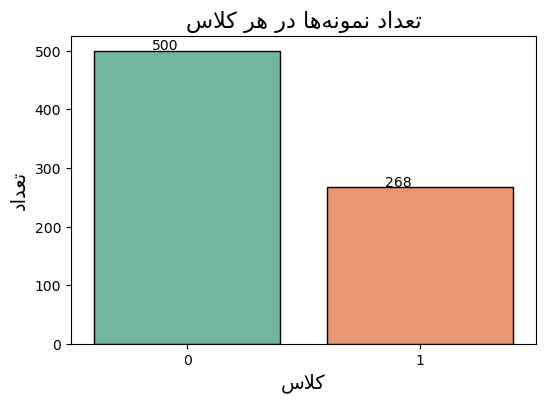

In [ ]:
# Class distribution analysis

plt.figure(figsize=(6,4))

sns.countplot(
    x="Outcome",
    data=df,
    palette="Set2",
    edgecolor="black"
)

plt.title("Class Distribution", fontsize=16)
plt.xlabel("Class", fontsize=14)
plt.ylabel("Count", fontsize=14)

# Display sample counts
for p in plt.gca().patches:
    plt.gca().annotate(
        f"{int(p.get_height())}",
        (p.get_x()+0.25, p.get_height()+1)
    )

plt.show()

🔹 Elbow Method

In [ ]:
inertia = []
for k in range(1,10):
    km = KMeans(n_clusters=k)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,10), inertia)
plt.show()

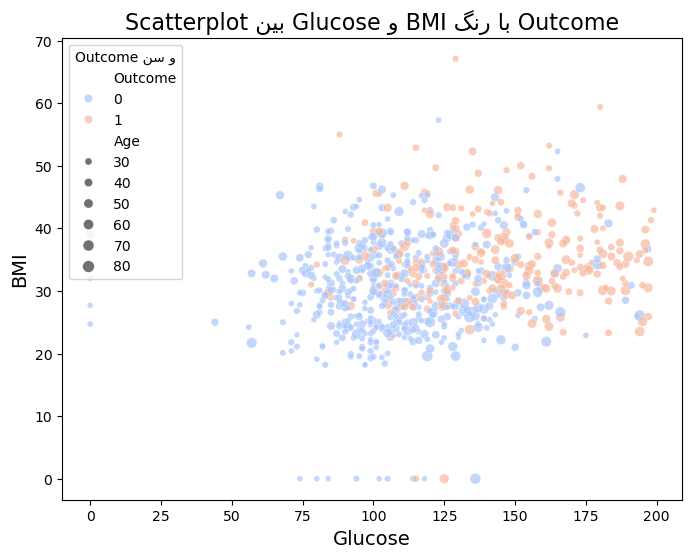

In [ ]:
# Relationship between Glucose and BMI

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Glucose",
    y="BMI",
    hue="Outcome",
    size="Age",
    data=df,
    palette="coolwarm",
    alpha=0.7
)

plt.title("Glucose vs BMI by Outcome", fontsize=16)
plt.xlabel("Glucose", fontsize=14)
plt.ylabel("BMI", fontsize=14)

plt.legend(title="Outcome & Age")

plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_18284\136984288.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df["Outcome"]==0]["Glucose"], shade=True, color="blue", label=vis.fa("کلاس 0"))
C:\Users\USER\AppData\Local\Temp\ipykernel_18284\136984288.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df["Outcome"]==1]["Glucose"], shade=True, color="red", label=vis.fa("کلاس 1"))


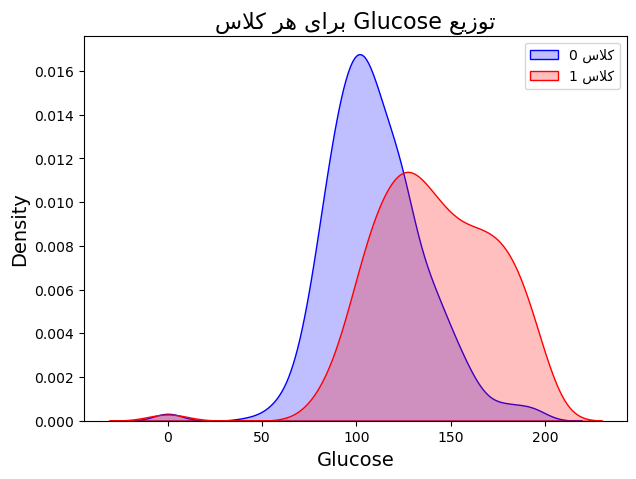

In [ ]:
# Glucose distribution by class

plt.figure(figsize=(7,5))

sns.kdeplot(
    df[df["Outcome"] == 0]["Glucose"],
    fill=True,
    label="Class 0"
)

sns.kdeplot(
    df[df["Outcome"] == 1]["Glucose"],
    fill=True,
    label="Class 1"
)

plt.title("Glucose Distribution by Class", fontsize=16)
plt.xlabel("Glucose", fontsize=14)
plt.ylabel("Density", fontsize=14)

plt.legend()

plt.show()

2026-02-21 11:59:37,661 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\USER\AppData\Local\Temp\ipykernel_18284\1027107609.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Outcome", y="BMI", data=df, palette="Set3", inner="quartile")
2026-02-21 11:59:37,678 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


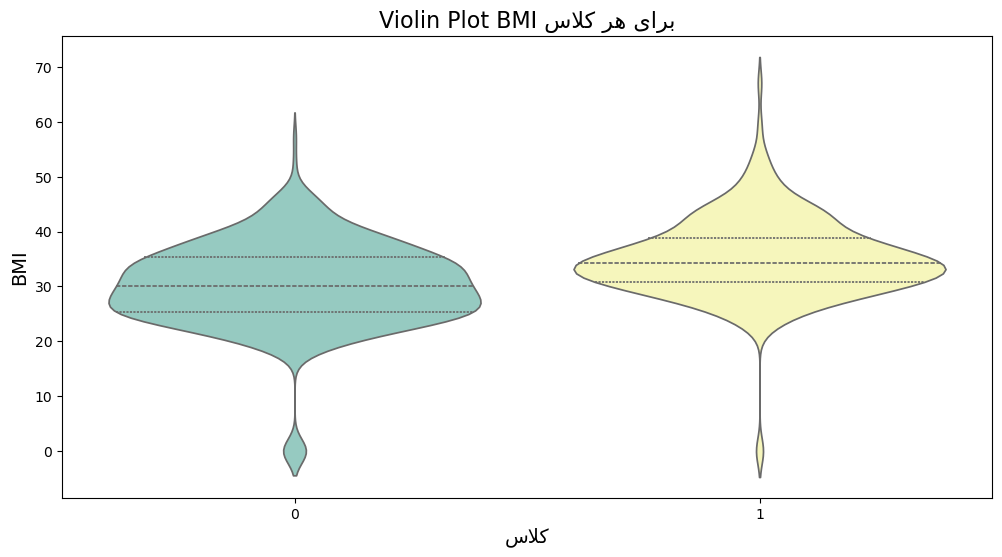

In [ ]:
# BMI distribution across classes

plt.figure(figsize=(12,6))

sns.violinplot(
    x="Outcome",
    y="BMI",
    data=df,
    palette="Set3",
    inner="quartile"
)

plt.title("BMI Distribution by Outcome", fontsize=16)
plt.xlabel("Class", fontsize=14)
plt.ylabel("BMI", fontsize=14)

plt.show()

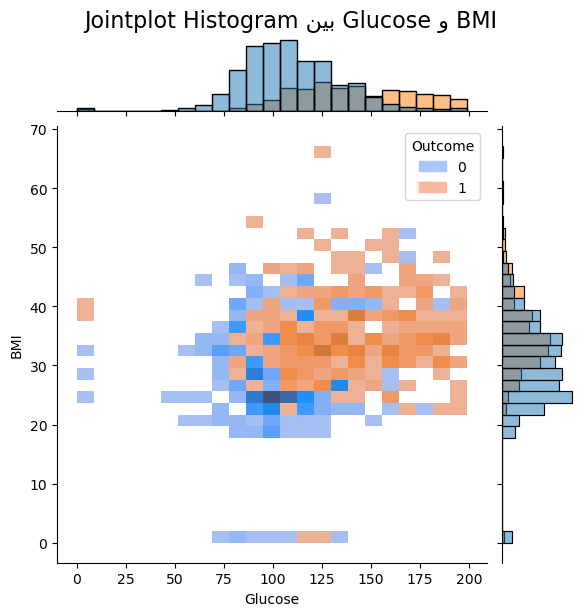

In [ ]:
# Joint distribution of Glucose and BMI

sns.jointplot(
    x="Glucose",
    y="BMI",
    data=df,
    hue="Outcome",
    kind="hist",
    palette="coolwarm",
    height=6
)

plt.suptitle(
    "Joint Distribution of Glucose and BMI",
    y=1.02,
    fontsize=16
)

plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_18284\1965662890.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x="Age", y="Glucose", data=df, ci=None, color="purple", marker="o")


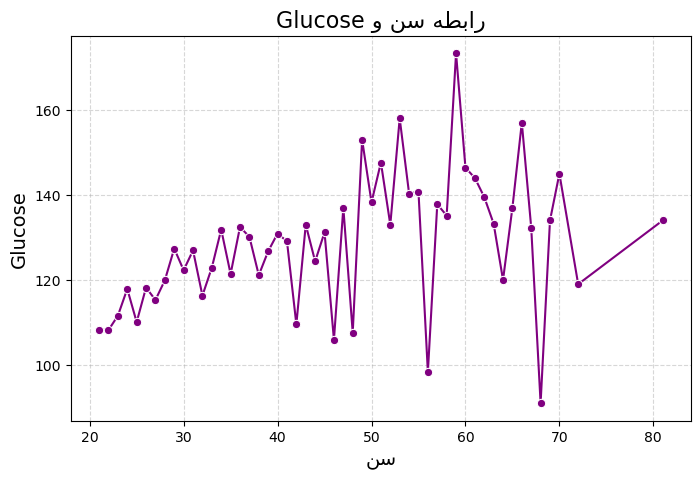

In [ ]:
# Relationship between Age and Glucose

plt.figure(figsize=(8,5))

sns.lineplot(
    x="Age",
    y="Glucose",
    data=df,
    marker="o"
)

plt.title("Age vs Glucose", fontsize=16)
plt.xlabel("Age", fontsize=14)
plt.ylabel("Glucose", fontsize=14)

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

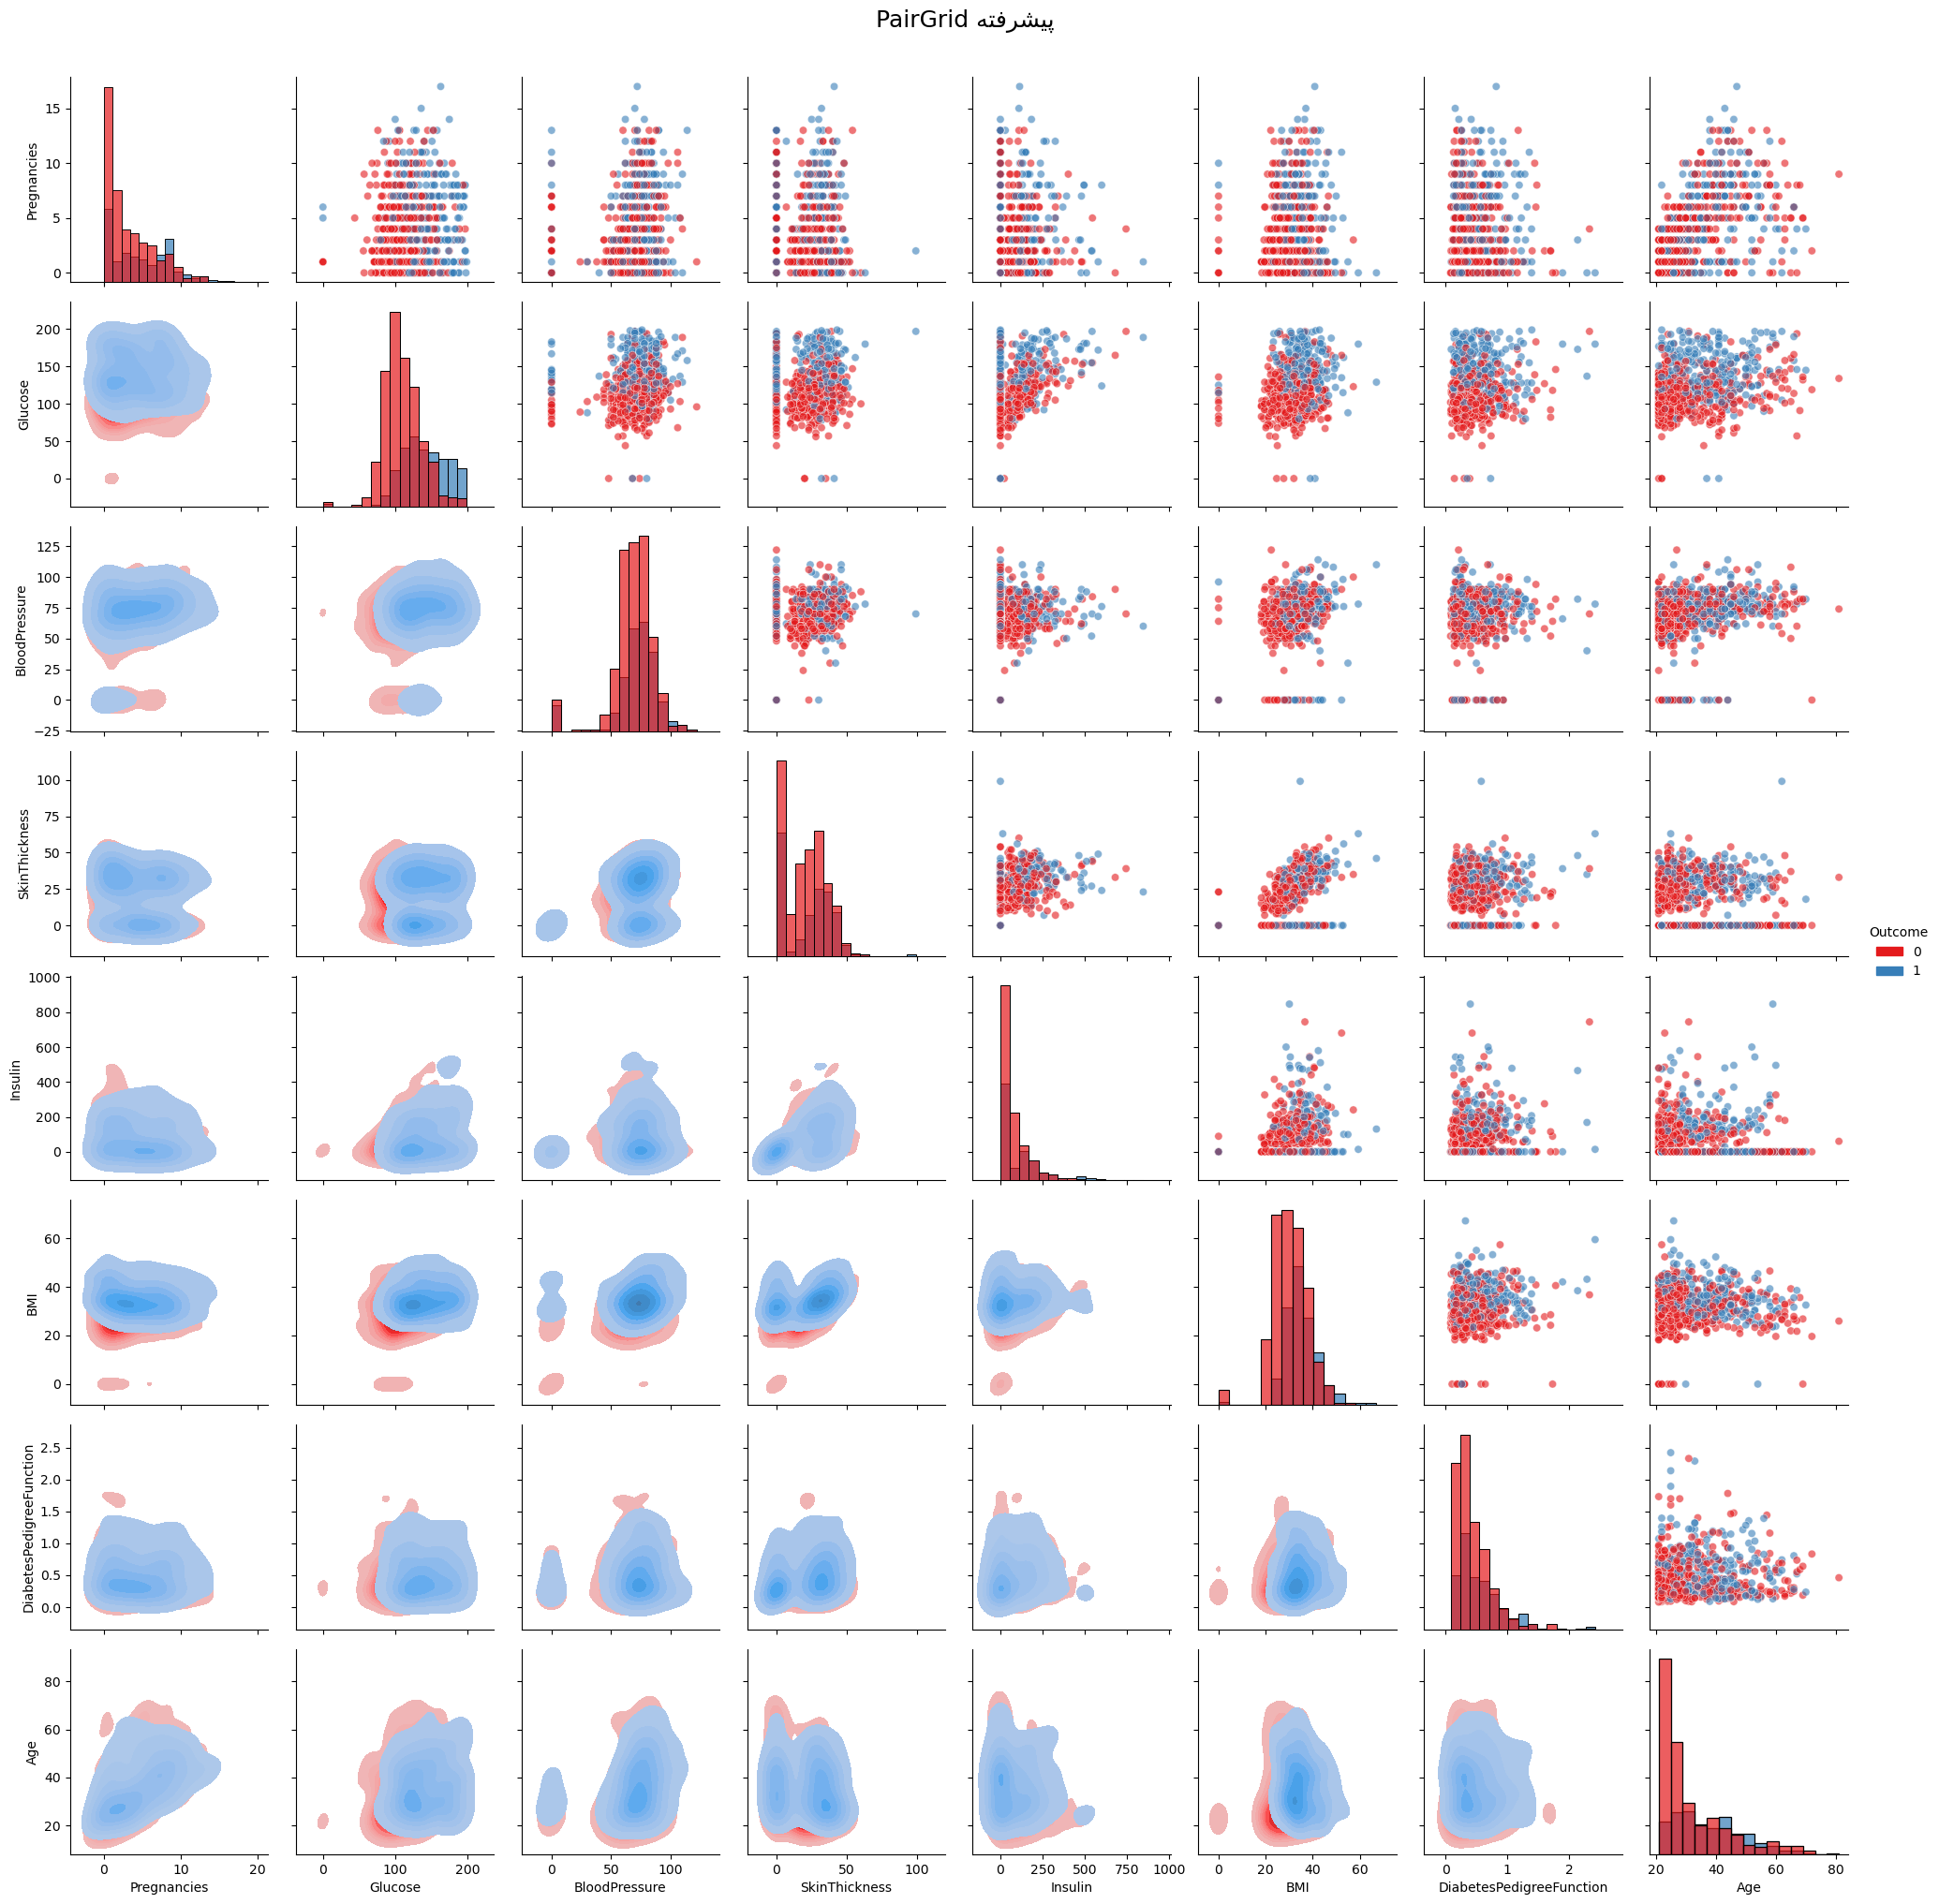

In [ ]:
# Advanced pairwise feature analysis

g = sns.PairGrid(
    df,
    hue="Outcome",
    palette="Set1",
    diag_sharey=False
)

g.map_upper(sns.scatterplot, alpha=0.6)

g.map_lower(sns.kdeplot, fill=True)

g.map_diag(sns.histplot, bins=15, alpha=0.7)

g.add_legend(title="Outcome")

plt.suptitle(
    "Advanced PairGrid Analysis",
    fontsize=18,
    y=1.02
)

plt.show()

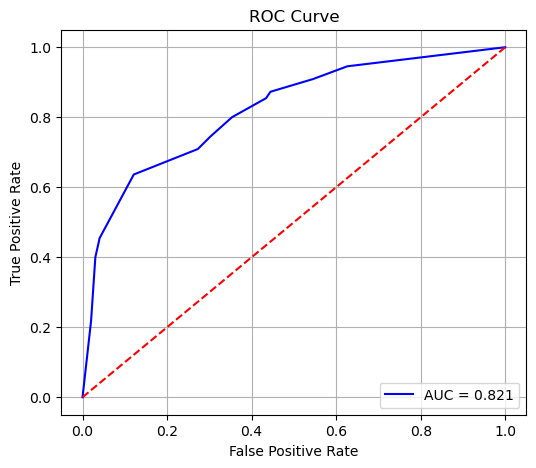

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

if hasattr(best_model, "predict_proba"):
    y_score = best_model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, color="blue", label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], color="red", linestyle="--")
    plt.title(vis.fa("ROC Curve"))
    plt.xlabel(vis.fa("False Positive Rate"))
    plt.ylabel(vis.fa("True Positive Rate"))
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

In [ ]:
# Helper function for rendering Persian text in plots

import arabic_reshaper
from bidi.algorithm import get_display

def fa(text):
    return get_display(
        arabic_reshaper.reshape(text)
    )

C:\Users\USER\AppData\Local\Temp\ipykernel_17096\3358633795.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=features[indices], palette="viridis", orient="h")


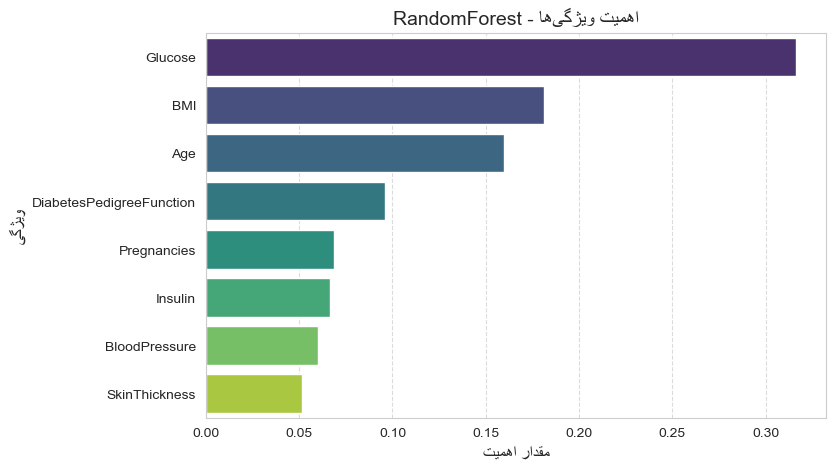

In [ ]:
# Random Forest feature importance

importances = rf_model.feature_importances_

features = df.drop(
    "Outcome",
    axis=1
).columns

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))

sns.barplot(
    x=importances[indices],
    y=features[indices],
    palette="viridis",
    orient="h"
)

plt.title(
    "Random Forest Feature Importance",
    fontsize=14
)

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.7
)

plt.show()

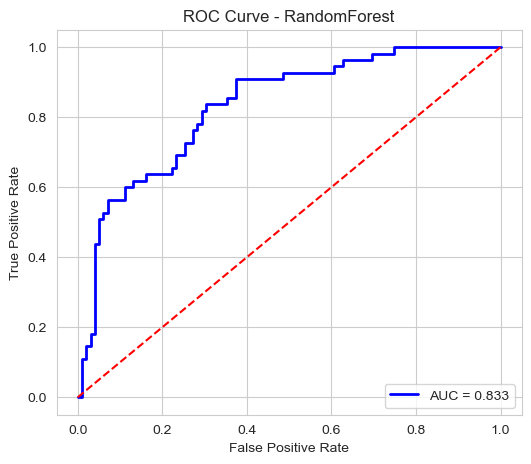

In [ ]:
if hasattr(rf_model, "predict_proba"):
    y_score = rf_model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], color="red", linestyle="--")
plt.title(fa("ROC Curve - RandomForest"))
plt.xlabel(fa("False Positive Rate"))
plt.ylabel(fa("True Positive Rate"))
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

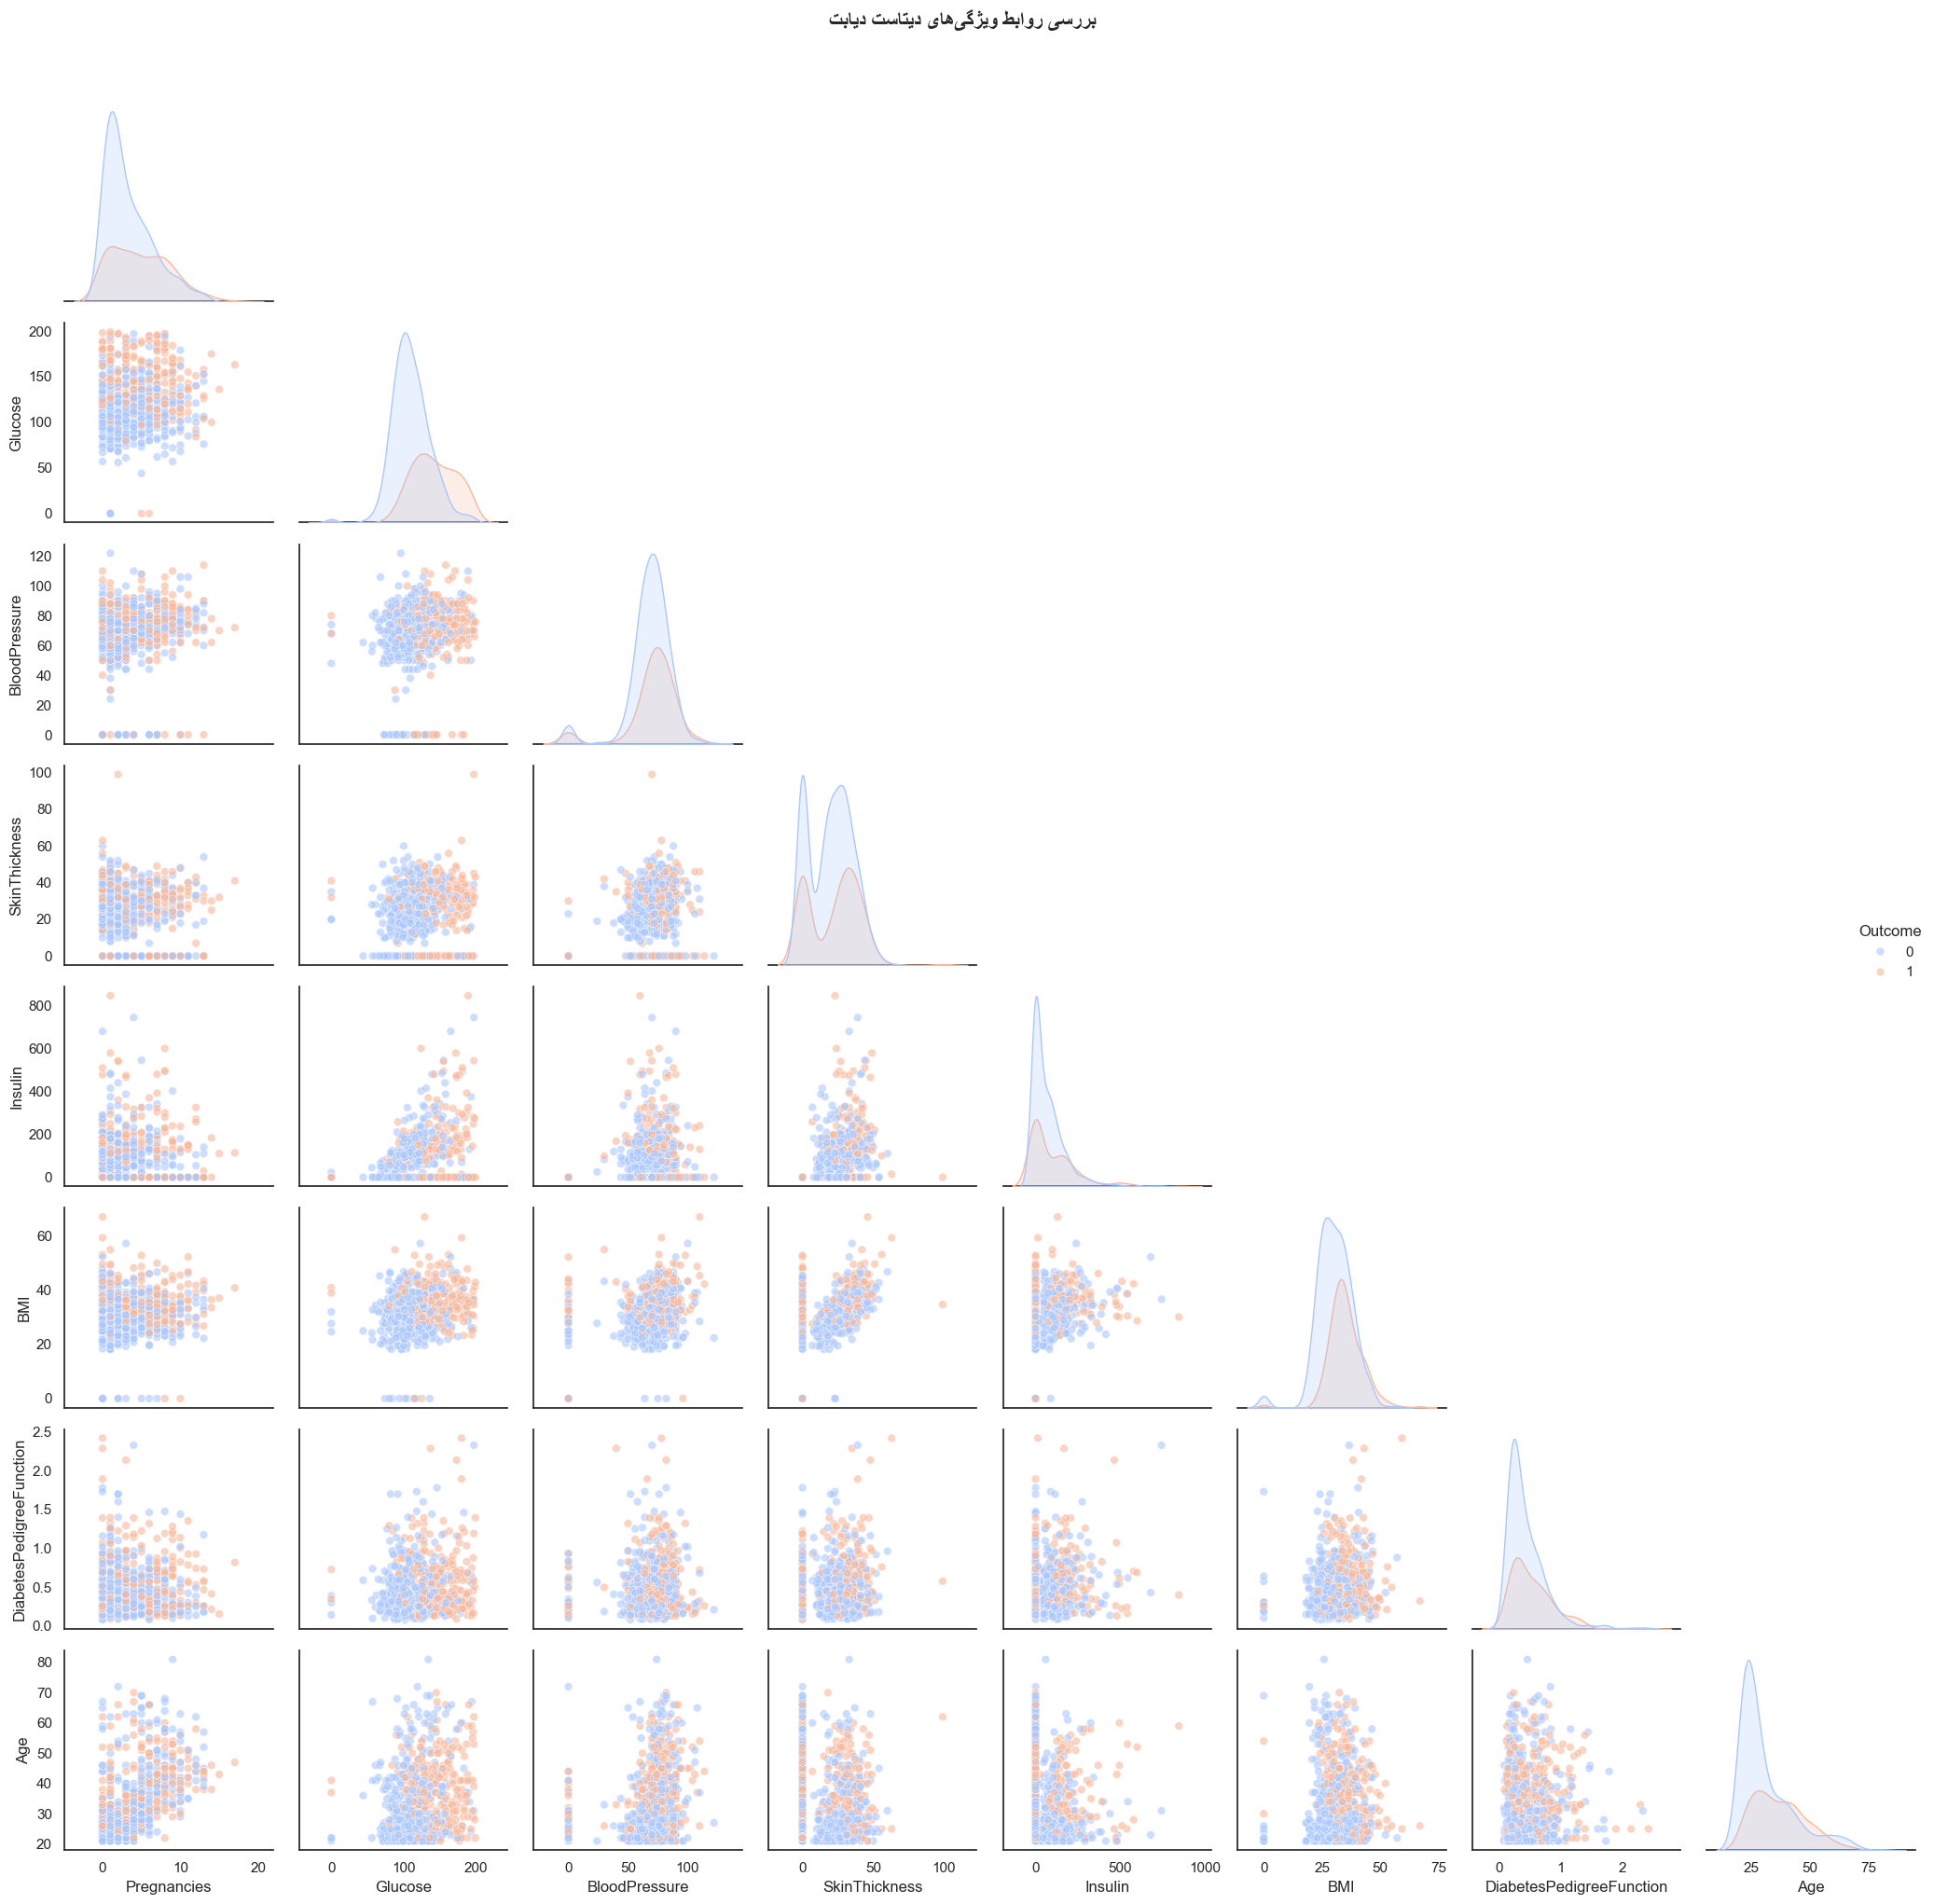

In [ ]:
# Pairwise feature relationships

vis = Visualizer()

sns.set_theme(style="white")

g = sns.pairplot(
    df,
    hue="Outcome",
    palette="coolwarm",
    diag_kind="kde",
    corner=True,
    plot_kws={
        "alpha": 0.6,
        "s": 40
    }
)

g.fig.suptitle(
    "Diabetes Dataset Feature Relationships",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

plt.show()

🔹ROC Curve

In [ ]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()

🔹Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {"n_neighbors":[3,5,7]}
grid = GridSearchCV(KNeighborsClassifier(), params, cv=5)
grid.fit(X_train, y_train)
print(grid.best_params_)

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {"n_neighbors":[3,5,7]}
grid = GridSearchCV(KNeighborsClassifier(), params, cv=5)
grid.fit(X_train, y_train)
print(grid.best_params_)

## ✅ Conclusion
- Random Forest achieved the best accuracy.
- Data preprocessing improved performance.
- Cross Validation confirmed model stability.

Future Work:
- Hyperparameter tuning
- Neural Networks
- Feature Engineering